In [1]:
%pip install tensorflow-probability[tf]
%pip install tensorflow

import os
os.environ["TRANSFORMERS_NO_TF"] = "1"  # This will prevent TensorFlow components from loading
from transformers import pipeline


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.





In [2]:
%pip install tensorflow tensorflow-probability
%pip install torch
%pip install transformers==4.x.x  # Replace `4.x.x` with a stable version compatible with your setup


from transformers import pipeline

# Load a text embedding pipeline using PyTorch
embedding_model = pipeline("feature-extraction", model="bert-base-uncased", framework="pt")
text_embedding = embedding_model("Sample text for embedding")[0]




Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: 'transformers==4.x.x': Expected end or semicolon (after version specifier)
    transformers==4.x.x
                ~~~^
C:\Users\nici_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from dateutil import parser

# Ensure downloaded these resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Path to the text folder
text_folder_path = r"C:\Users\nici_\OneDrive\Desktop\Masterarbeit\Factsheets\Text"

# Define stopwords and lemmatizer
custom_stopwords = {
    'der', 'die', 'das', 'den', 'des', 'le', 'la', 'les', 'de', 'et', 'und', 'davon', 'per', 'name', 
    'postcode', 'address', 'phone', 'company', 'ag', 'am',  'namen', 'bbb', 'inhalt', 'total', 'anhang,'
    'management', 'phone', 'telefon', 'telefax', 'email', 'weiterhin', 'com', 'whg', 'senior', 'seite', 'www',
    'u', 'ab', 'seit', 'mehr', 'company_1', 'company_2','company_3', 'company_4', 'company_5','company_6',   
 
  # Pronouns and articles not in NLTK
    'ich', 'du', 'er', 'wir', 'ihr', 'uns', 'mein', 'dein', 'sein', 'unser', 'euer', 'deren', 'dessen',
    
    # Common conjunctions and prepositions not in NLTK
    'obwohl', 'trotz', 'denn', 'doch', 'da', 'weder', 'noch', 'falls', 'sowie', 'entweder', 'trotzdem',
    'daher', 'deswegen', 'hinzu', 'daraufhin', 'hinweg', 'hierbei',
    
    # Additional time-related words
    'heute', 'morgen', 'gestern', 'jetzt', 'sofort', 'bald', 'manchmal', 'früh', 'spät', 'vorher', 'danach',
    'eben', 'gerade', 'schon', 'bereits', 'weiterhin', 'zudem', 'fort', 'sofort',
    
    # Other frequent words
    'jedoch', 'vielleicht', 'beispielsweise', 'beispiel', 'eigentlich', 'alle', 'meist', 'sagen', 'machen', 
    'gut', 'schlecht', 'wenig', 'viel', 'vielen', 'ebenfalls', 'nein', 'ja', 'teil', 'sehr', 'hier', 'dort',
    'auch', 'beim', 'viele', 'alle', 'mehr', 'dann', 'immer', 'einige', 'jemand', 'niemand', 'mehrere', 'solche'
    

    'ersten', 'zweiten', 'leicht', 'kopie', 'gegenüber', 'insbesondere', 'flexiblen', 'stark', 'aufgrund',
    # Common English stopwords
    'therefore', 'thus', 'furthermore', 'additionally', 'also', 'however', 'could', 'would', 'might', 'must',
    'should', 'including', 'etc', 'either', 'neither', 'one', 'two', 'three', 'first', 'second', 'third', 'many',
}
stop_words = set(stopwords.words('english')) | set(stopwords.words('german')) | set(stopwords.words('french')) | custom_stopwords
lemmatizer = WordNetLemmatizer()

# Define month names for regex-based date extraction in multiple languages
month_names = [
    "january", "february", "march", "april", "may", "june", "july", "august", "september", "october", "november", "december",
    "jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec",
    "janvier", "février", "mars", "avril", "mai", "juin", "juillet", "août", "septembre", "octobre", "novembre", "décembre",
    "janv", "févr", "avr", "août", "sept", "oct", "nov", "déc",
    "januar", "februar", "märz", "april", "mai", "juni", "juli", "august", "september", "oktober", "november", "dezember",
    "jan", "feb", "mär", "apr", "jun", "jul", "aug", "sep", "okt", "nov", "dez"
]
month_stopwords = set(month_names)  # For filtering months post date extraction

# Date pattern to match various date formats in English, French, and German
date_pattern = (
    r"\b(?:\d{1,2}[-/\s]?)?"
    + r"(?:" + "|".join(month_names) + r")[-/\s]?"
    + r"(?:\d{2,4})?\b"
    + r"|\b\d{1,2}[-/\s]\d{1,2}[-/\s]\d{2,4}\b"
)

# Define a mapping for normalizing similar terms
word_mapping = {
    "aktienähnliche": "aktien",

}

# Function to standardize and clean text
def standardize_text(text):
    text = re.sub(r'\s+', ' ', text).strip()
    aligned_text = '\n'.join(line.lstrip() for line in text.splitlines())
    return aligned_text

# Function to extract dates using regex and parse them
def extract_dates(text):
    dates = []
    for match in re.finditer(date_pattern, text, flags=re.IGNORECASE):
        try:
            parsed_date = parser.parse(match.group(), fuzzy=True, dayfirst=True)
            dates.append(parsed_date.isoformat())
        except (ValueError, parser.ParserError):
            continue
    return dates if dates else None

# Function to preprocess text by removing stopwords, numbers, and performing lemmatization
def preprocess_text_for_topic_modeling(text):
    text = text.lower()
    
    # Remove all numbers, including years
    text = re.sub(r'\b\d+\b', '', text)
    
    # Remove non-alphanumeric characters
    text = re.sub(r'\W', ' ', text)

    processed_words = []
    for word in text.split():
        # Remove short words (length <= 2), stopwords, and words with minimal meaning
        if len(word) > 2 and word not in stop_words and word not in month_stopwords:
            word = lemmatizer.lemmatize(word)
            # Apply word mapping if applicable
            word = word_mapping.get(word, word)
            processed_words.append(word)

    return ' '.join(processed_words)



text_data = {}
for file in os.listdir(text_folder_path):
    if file.endswith(".txt"):
        with open(os.path.join(text_folder_path, file), 'r', encoding='utf-8') as f:
            raw_text = f.read()
            standardized_text = standardize_text(raw_text)  # Standardize and align text
            
            # Extract dates with years
            extracted_dates = extract_dates(standardized_text)
            
            # Preprocess text for topic modeling (without years or numbers)
            preprocessed_text_for_modeling = preprocess_text_for_topic_modeling(standardized_text)
            
            # Store both preprocessed text and extracted dates
            text_data[file] = {
                "dates": extracted_dates,
                "processed_text": preprocessed_text_for_modeling
            }

# Display extracted dates and processed text examples
for file, content in list(text_data.items())[:3]:  # Display first 3 for brevity
    print(f"\nFile: {file}")
    print(f"Extracted Dates: {content['dates']}")
    print(f"Preprocessed Text:\n{content['processed_text'][:500]}")  # Show first 500 characters of preprocessed text
    
# Collect all processed texts into a list for topic modeling
documents = [content["processed_text"] for content in text_data.values()]



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nici_\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nici_\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nici_\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!



File: 20140930_[COMPANY_2]_10011435-001_350565_001001_page_1.txt
Extracted Dates: ['2014-09-06T00:00:00']
Preprocessed Text:
reporting kundeninformationen stiftung altersrücktritt bauhauptgewerbe far mandat kundenanlageprofil referenzwährung chf betreuungsart custody anlagestrategie balanced ansprechpartner marco kälin mail mail www

File: 20140930_[COMPANY_2]_10011435-001_350565_001001_page_10.txt
Extracted Dates: ['2014-09-06T00:00:00', '2014-11-06T00:00:00', '2013-11-06T00:00:00', '2014-09-06T00:00:00', '2024-01-14T00:00:00', '2024-02-14T00:00:00', '2024-11-14T00:00:00', '2024-04-14T00:00:00', '2024-11-14T00:00:00', '2024-06-14T00:00:00', '2024-07-14T00:00:00', '2024-08-14T00:00:00', '2024-09-14T00:00:00', '2024-01-14T00:00:00', '2024-02-14T00:00:00', '2024-11-14T00:00:00', '2024-04-14T00:00:00', '2024-11-14T00:00:00', '2024-06-14T00:00:00', '2024-07-14T00:00:00', '2024-08-14T00:00:00', '2024-09-14T00:00:00']
Preprocessed Text:
performanceverlauf reporting erstellt performance datu

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Extract only the "processed_text" entries from text_data
cleaned_texts = [content["processed_text"] for content in text_data.values()]

# Apply TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = vectorizer.fit_transform(cleaned_texts)

# Check the shape of the TF-IDF matrix to ensure proper vectorization
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)


TF-IDF Matrix Shape: (1391, 1000)


In [5]:
from sklearn.cluster import KMeans

# Set the number of clusters (adjust based on domain knowledge or trial)
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(tfidf_matrix)

# Print top keywords for each cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

print("\nTop Keywords per Cluster:")
for i in range(num_clusters):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}: {', '.join(top_terms)}")



Top Keywords per Cluster:
Cluster 0: wertveränderungen, vermögen, nettoflüsse, erträge, kontribution, netto, quellensteuern, gesamterfolg, performance, adjustiert
Cluster 1: usd, inc, chf, aktien, gesundheitswesen, veränd, eur, devisenkurs, finanzwesen, aaa
Cluster 2: chf, cad, jpy, kontokorrent, aud, marchzinsen, dkk, gegenwert, devisenkurs, gbp
Cluster 3: eur, aktien, finanzwesen, inhaber, chf, gbp, veränd, usd, energie, plc
Cluster 4: gbp, nok, obligationen, aktien, eur, chf, allokation, usd, anlage, gesamtvermögen
Cluster 5: chf, veränd, obligationen, devisenkurs, bewertung, baa1, fälligkeit, isin, marktwert, preis
Cluster 6: quartal, prozent, dollar, usa, anleihen, management, ersten, deutlich, übergewichteten, strategie
Cluster 7: kundeninformationen, custody, betreuungsart, referenzwährung, altersrücktritt, stiftung, anlagestrategie, far, www, kundenbetreuer
Cluster 8: differenz, benchmark, portfoliowert, portfolio, performanceberechnung, reporting, netto, performanceverlauf, d

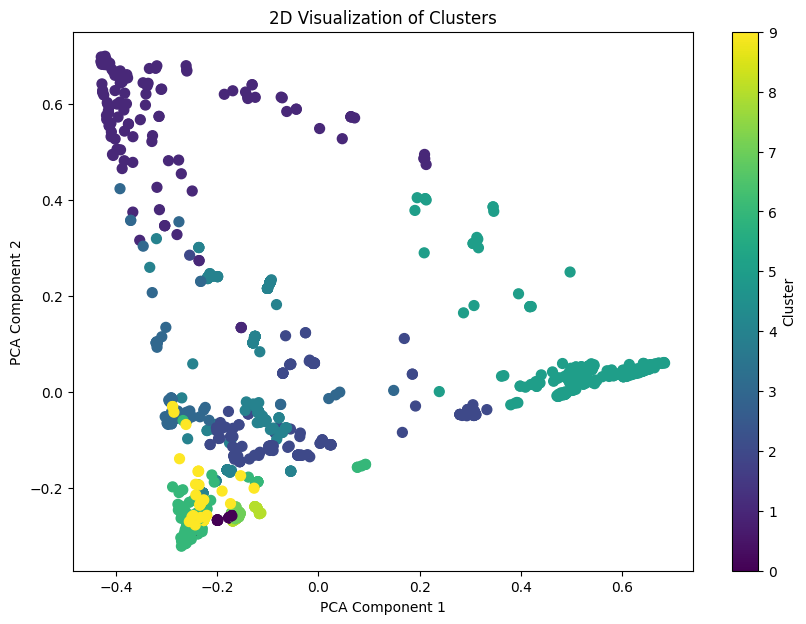

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce the dimensions for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(tfidf_matrix.toarray())

# Plot the clusters
plt.figure(figsize=(10, 7))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='viridis', s=50)
plt.title("2D Visualization of Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

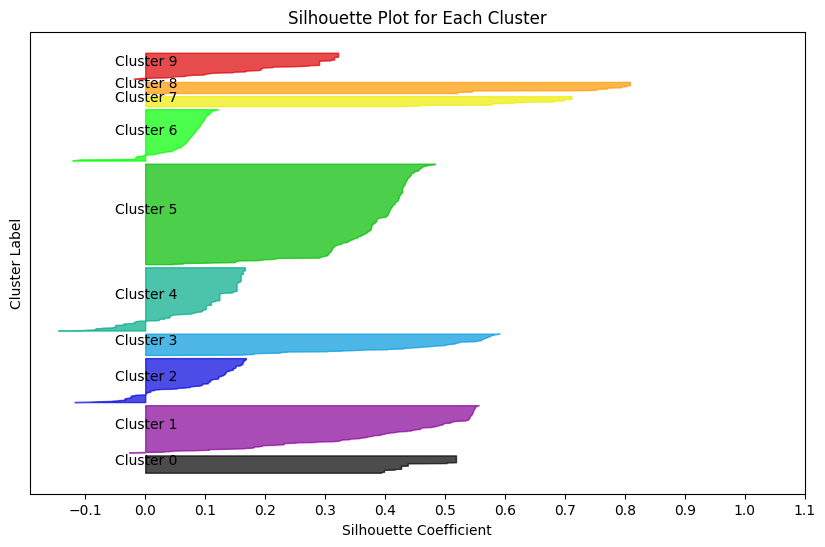

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples

# Compute the silhouette scores for each sample
sample_silhouette_values = silhouette_samples(tfidf_matrix, labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10  # Starting position for the plot

for i in range(num_clusters):
    # Aggregate the silhouette scores for samples in the cluster
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    cluster_size = len(ith_cluster_silhouette_values)
    y_upper = y_lower + cluster_size

    color = cm.nipy_spectral(float(i) / num_clusters)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7
    )

    ax.text(-0.05, y_lower + 0.5 * cluster_size, f"Cluster {i}")
    y_lower = y_upper + 10  # 10 for spacing between clusters

ax.set_title("Silhouette Plot for Each Cluster")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster Label")

# Vertical line for average silhouette score
ax.set_yticks([])  # Clear the y-axis labels
ax.set_xticks(np.arange(-0.1, 1.1, 0.1))

plt.show()



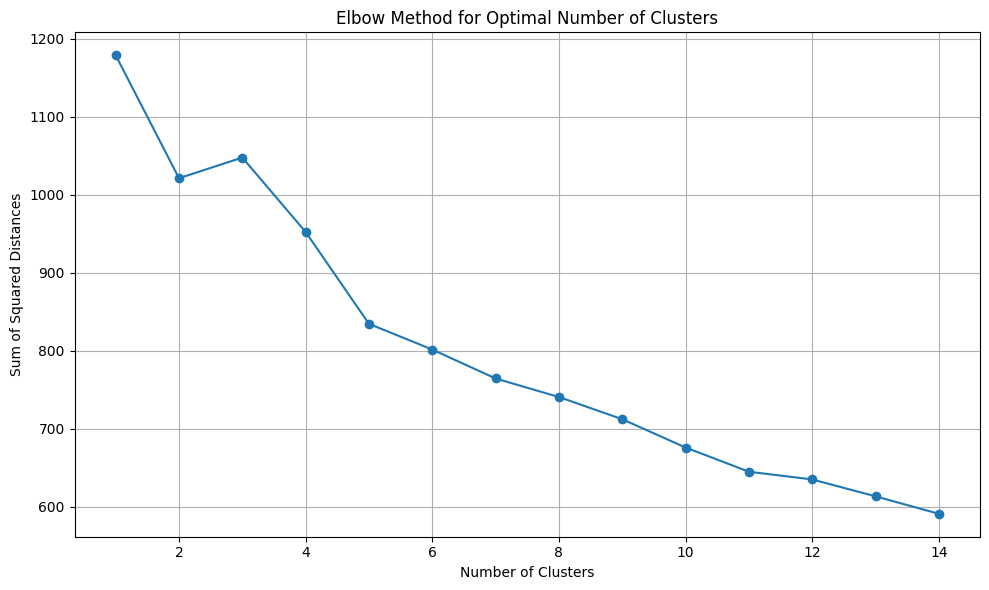

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# Generate an elbow plot to find the optimal number of clusters
sse = []  # Sum of squared distances
cluster_range = range(1, 15)  # Range of clusters to try

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tfidf_matrix)
    sse.append(kmeans.inertia_)  # Append the sum of squared distances for each k

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, sse, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances')
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score
silhouette_avg = silhouette_score(tfidf_matrix, labels)
print(f"Silhouette Score: {silhouette_avg:.2f}")


Silhouette Score: 0.27


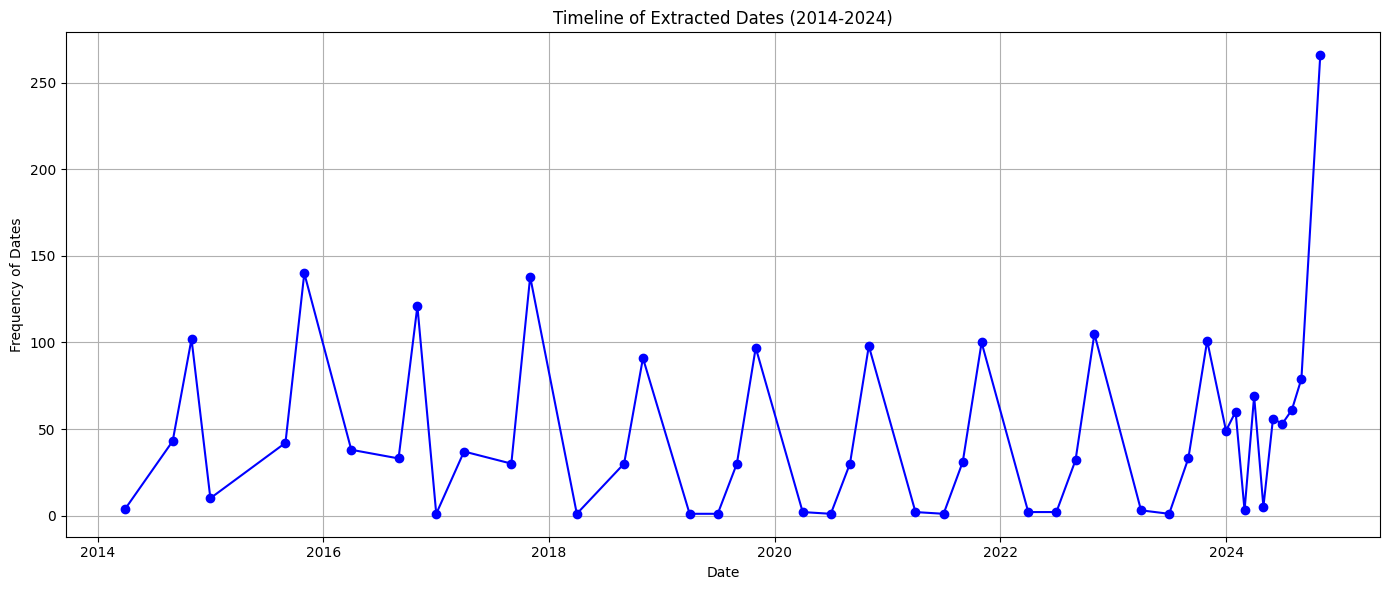

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Collect all extracted dates from the `text_data` dictionary
all_dates = []
for file, content in text_data.items():
    text = content.get("processed_text", "")  # Get only the processed text content
    extracted_dates = content.get("dates", [])  # Use the pre-extracted dates
    if extracted_dates:
        all_dates.extend(pd.to_datetime(extracted_dates, errors='coerce'))

# Remove any NaT values that couldn't be parsed correctly
all_dates = [date for date in all_dates if pd.notnull(date)]

# Filter dates within the range of 2014 and 2024
all_dates = [date for date in all_dates if 2014 <= date.year <= 2024]

# Aggregate dates by month
date_counts = pd.Series(all_dates).dt.to_period('M').value_counts().sort_index()

# Convert to a DataFrame for plotting
date_counts_df = date_counts.to_frame('Frequency')
date_counts_df.index = date_counts_df.index.to_timestamp()

# Plot the timeline within the specified range
plt.figure(figsize=(14, 6))
plt.plot(date_counts_df.index, date_counts_df['Frequency'], marker='o', linestyle='-', color='b')
plt.title("Timeline of Extracted Dates (2014-2024)")
plt.xlabel("Date")
plt.ylabel("Frequency of Dates")
plt.grid(True)
plt.tight_layout()
plt.show()


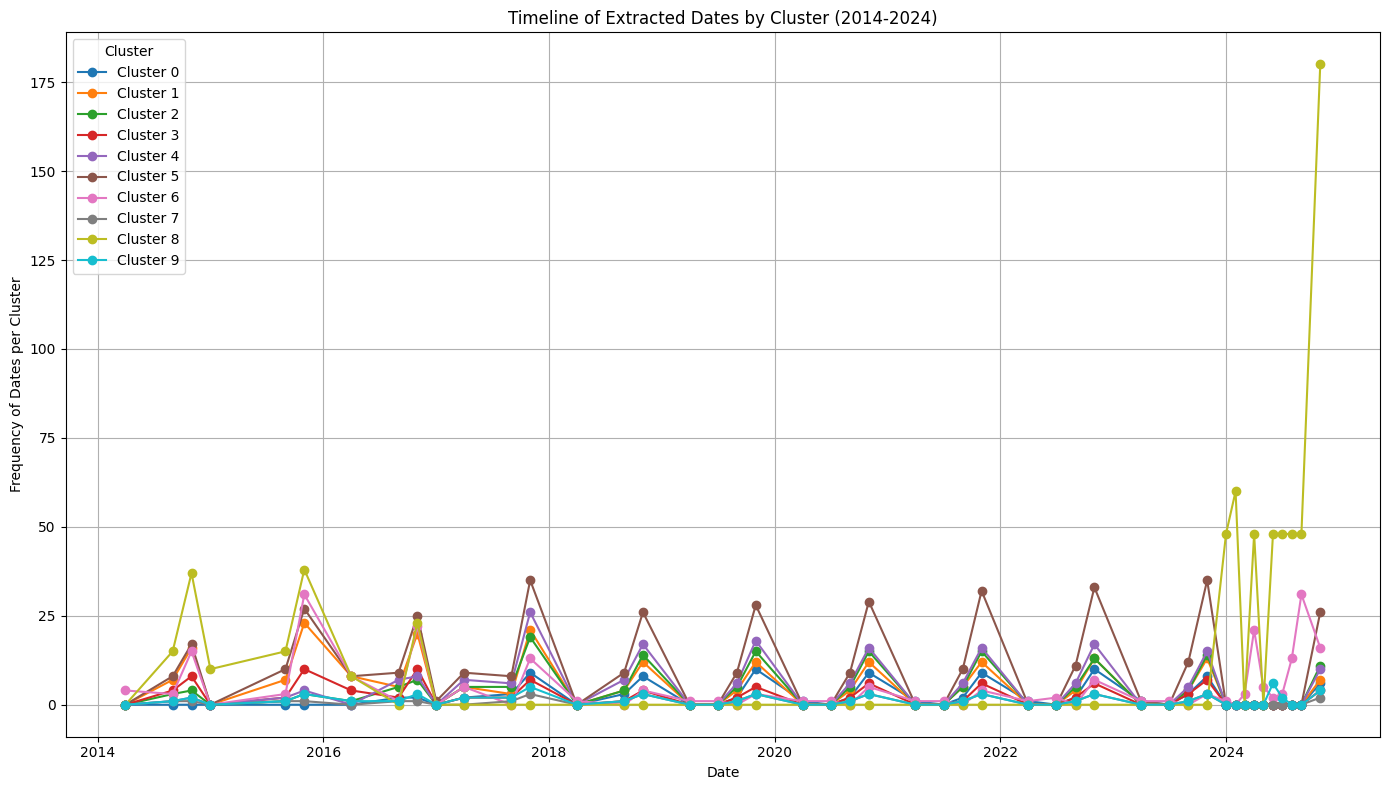

In [16]:
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Initialize a data structure to store dates per cluster
cluster_date_data = defaultdict(list)

# Step 2: Extract dates and align them with their clusters
for file_idx, (file, content) in enumerate(text_data.items()):
    cluster = labels[file_idx]  # Get the cluster label from the clustering model
    extracted_dates = content.get("dates", [])  # Use the pre-extracted dates

    # Convert extracted dates to valid datetime objects and filter valid years
    if extracted_dates:
        parsed_dates = pd.to_datetime(extracted_dates, errors='coerce')
        valid_dates = [date for date in parsed_dates if pd.notnull(date) and 2014 <= date.year <= 2024]
        
        # Append the valid dates to the cluster's list
        cluster_date_data[cluster].extend(valid_dates)

# Step 3: Create a DataFrame for visualization
cluster_date_df = pd.DataFrame(
    [(date, cluster) for cluster, dates in cluster_date_data.items() for date in dates],
    columns=['Date', 'Cluster']
)

# Convert 'Date' to monthly periods for aggregation
cluster_date_df['Date'] = cluster_date_df['Date'].dt.to_period('M')

# Step 4: Aggregate counts by month and cluster
date_cluster_counts = cluster_date_df.groupby(['Date', 'Cluster']).size().unstack(fill_value=0)

# Step 5: Plot the data
plt.figure(figsize=(14, 8))
for cluster in date_cluster_counts.columns:
    plt.plot(
        date_cluster_counts.index.to_timestamp(),
        date_cluster_counts[cluster],
        marker='o',
        linestyle='-',
        label=f'Cluster {cluster}'
    )

plt.title("Timeline of Extracted Dates by Cluster (2014-2024)")
plt.xlabel("Date")
plt.ylabel("Frequency of Dates per Cluster")
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
from collections import defaultdict
import pandas as pd

# Initialize data structures for word tracking
word_time_data = defaultdict(lambda: defaultdict(int))
total_word_count_per_date = defaultdict(int)

# Populate word counts per date
for file, content in text_data.items():
    extracted_dates = content.get("dates", [])
    processed_text = content.get("processed_text", "")
    
    # Proceed only if extracted_dates is not None
    if extracted_dates:
        # Convert extracted dates to datetime objects and filter valid years
        parsed_dates = pd.to_datetime(extracted_dates, errors='coerce').dropna()
        valid_dates = [date for date in parsed_dates if 2014 <= date.year <= 2024]

        # Count words for each valid date
        words = processed_text.split()
        for date in valid_dates:
            date_str = date.strftime('%Y-%m-%d')
            total_word_count_per_date[date_str] += len(words)
            for word in words:
                word_time_data[date_str][word] += 1

# Step 1: Print word_time_data to check term counts per date
print("Contents of word_time_data (first 5 dates):\n", list(word_time_data.items())[:5])

# Step 2: Print total_word_count_per_date to check word counts per date
print("Total Word Count per Date (first 5 dates):\n", list(total_word_count_per_date.items())[:5])

# Convert word_time_data to DataFrame and calculate probabilities if data is present
if word_time_data:
    word_time_df = pd.DataFrame(word_time_data).T.fillna(0)
    word_probability_df = word_time_df.div(pd.Series(total_word_count_per_date), axis=0).fillna(0)

    # Display a preview of the probability distribution DataFrame
    print("Probability Distribution of Terms Over Time:\n")
    print(word_probability_df.head())
else:
    print("word_time_data is empty; check data extraction and processing steps.")


Contents of word_time_data (first 5 dates):
 [('2014-09-06', defaultdict(<class 'int'>, {'reporting': 43, 'kundeninformationen': 1, 'stiftung': 1, 'altersrücktritt': 1, 'bauhauptgewerbe': 1, 'far': 1, 'mandat': 1, 'kundenanlageprofil': 1, 'referenzwährung': 2, 'chf': 207, 'betreuungsart': 1, 'custody': 1, 'anlagestrategie': 2, 'balanced': 1, 'ansprechpartner': 1, 'marco': 1, 'kälin': 1, 'mail': 2, 'www': 1, 'performanceverlauf': 12, 'erstellt': 42, 'performance': 56, 'datum': 12, 'portfoliowert': 25, 'rendite': 24, 'portfolio': 42, 'benchmark': 43, 'differenz': 40, 'iii': 13, 'performanceberechnung': 14, 'netto': 14, 'informationen': 43, 'detailpositionen': 42, 'anhang': 42, 'segmentperformance': 2, 'liquidität': 8, 'obligationen': 36, 'itä': 3, 'sla': 3, 'tie': 6, 'vermögensstruktur': 2, 'marktwert': 25, 'ökonomisches': 3, 'exposure': 4, 'strategie': 5, 'derivate': 2, 'einfluss': 1, 'abweichung¹': 1, 'ökonomischen': 1, 'bandbreite': 1, 'marktwerts': 1, 'anlagestruktur': 1, 'tio': 1, '

In [21]:
from transformers import pipeline
from sklearn.cluster import KMeans
from collections import defaultdict

# Load a pre-trained BERT model for feature extraction
embedding_pipeline = pipeline(
    "feature-extraction", 
    model="bert-base-uncased", 
    tokenizer="bert-base-uncased",
    truncation=True,       # Enable truncation to handle long documents
    max_length=512         # Set max length to BERT's maximum token limit
)

# Generate embeddings for each document
document_embeddings = [embedding_pipeline(text)[0][0] for text in cleaned_texts]  # Iterate over cleaned_texts directly

# Apply KMeans clustering to embeddings
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(document_embeddings)

# Analyze and print cluster details
cluster_analysis = defaultdict(list)
for idx, label in enumerate(labels):
    cluster_analysis[label].append(idx)  # Use the index to refer to the document's position in cleaned_texts

# Display cluster details
for cluster, docs in cluster_analysis.items():
    print(f"Cluster {cluster}: Document Indices {docs[:5]}")  # Show first 5 document indices in each cluster


C:\Users\nici_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Cluster 9: Document Indices [0, 22, 38, 60, 81]
Cluster 0: Document Indices [1, 2, 5, 11, 32]
Cluster 8: Document Indices [3, 4, 41, 42, 57]
Cluster 5: Document Indices [6, 7, 8, 20, 30]
Cluster 6: Document Indices [9, 10, 12, 13, 14]
Cluster 2: Document Indices [27, 28, 29, 65, 66]
Cluster 3: Document Indices [77, 78, 79, 80, 119]
Cluster 1: Document Indices [219, 220, 221, 222, 223]
Cluster 4: Document Indices [228, 266, 303, 338, 375]
Cluster 7: Document Indices [230, 249, 267, 304, 305]


In [22]:
# Install compatible versions for gensim (4.3.3) and numpy (1.26.4)
%pip install numpy==1.26.4 gensim==4.3.3

from gensim import corpora
from gensim.models import LdaModel
from gensim.matutils import Sparse2Corpus

for cluster_num in set(labels):
    print(f"\nLDA Topic Analysis for Cluster {cluster_num}")

    # Filter documents in this cluster
    cluster_texts = [cleaned_texts[i] for i, label in enumerate(labels) if label == cluster_num]

    # Create dictionary and corpus for LDA
    dictionary = corpora.Dictionary([text.split() for text in cluster_texts])
    corpus = [dictionary.doc2bow(text.split()) for text in cluster_texts]

    # Train LDA model
    lda_model = LdaModel(corpus, num_topics=3, id2word=dictionary, random_state=42)
    topics = lda_model.print_topics(num_words=5)
    for topic in topics:
        print(f"Topic {topic[0]}: {topic[1]}")




LDA Topic Analysis for Cluster 0
Topic 0: 0.068*"obligationen" + 0.063*"chf" + 0.050*"differenz" + 0.049*"detailpositionen" + 0.043*"benchmark"
Topic 1: 0.080*"chf" + 0.065*"benchmark" + 0.057*"differenz" + 0.049*"portfolio" + 0.047*"obligationen"
Topic 2: 0.102*"portfolio" + 0.099*"benchmark" + 0.090*"differenz" + 0.076*"performance" + 0.061*"rendite"

LDA Topic Analysis for Cluster 1
Topic 0: 0.308*"chf" + 0.033*"devisenkurs" + 0.031*"veränd" + 0.027*"obligationen" + 0.019*"performance"
Topic 1: 0.308*"chf" + 0.055*"bewertung" + 0.034*"veränd" + 0.032*"devisenkurs" + 0.031*"obligationen"
Topic 2: 0.346*"chf" + 0.041*"veränd" + 0.034*"obligationen" + 0.033*"devisenkurs" + 0.018*"detailpositionen"

LDA Topic Analysis for Cluster 2
Topic 0: 0.047*"usd" + 0.027*"eur" + 0.021*"aktien" + 0.020*"chf" + 0.014*"veränd"
Topic 1: 0.268*"usd" + 0.041*"chf" + 0.036*"aktien" + 0.030*"inc" + 0.028*"gesundheitswesen"
Topic 2: 0.244*"usd" + 0.040*"inc" + 0.038*"aktien" + 0.035*"chf" + 0.028*"gesund